### **Chapter 6.4: Data-Enabled Predictive Control**

Chapters 6.1 to 6.3 followed the **indirect** route to learning-based control: collect data, identify a model (by linear regression, Bayesian linear regression, or a Gaussian process), and hand the model to a predictive controller. This chapter takes the **direct** route. **Data-enabled predictive control (DeePC)** skips the identification step altogether: one recorded input-output trajectory replaces the prediction model inside the MPC, and the controller optimizes directly over the data.

The theoretical basis is **Willems' fundamental lemma**: for a controllable linear time-invariant (LTI) system, a single trajectory whose input is sufficiently rich spans *all* trajectories of a given length. A Hankel matrix built from that trajectory therefore does everything a state-space model does in Chapter 5, and DeePC is the MPC that uses it. The questions that decide whether this works in practice are then:

- **How much data is needed?** The lemma gives a counting bound. We check whether it is sharp, and what happens below it.

- **What happens when the plant is not LTI, or the data are noisy?** The lemma is exact only under its assumptions. On the bumpy terrain the recorded data are not consistent with any LTI behavior, and the controller needs **regularization** to remain useful. We look at what regularization buys, what it costs, and how sensitive the result is to its tuning.

- **Direct or indirect?** With the same noisy data from the same nonlinear plant one can either fit a model and run MPC, or run DeePC. On the bumpy terrain of Chapter 6.3 we compare the two routes and ask which degrades more gracefully as the data get worse.

Throughout this chapter DeePC measures **only the position**, $y = p$, and never sees the velocity. This is the defining property of the method: it works with input-output data alone, and the recent input-output history takes over the role that the state plays in MPC. We return to the flat terrain (`case = 1`) so that the plant is LTI where the theory demands it, and move to the bumpy terrain when we want to leave the assumptions behind.

The content is summarized in the table below.

<style>
  table td:nth-child(2) {
    text-align: left;
  }
</style>

<table border="1" style="border-collapse: collapse;">  <!-- Title Row -->
  <tr>
    <th colspan="2" style="text-align:center">Chapter 6.4</th>
  </tr>

  <!-- Row group 1 -->
  <tr>
    <td rowspan="2">Fundamental Lemma and DeePC</td>
    <td>Example 1.1: One Trajectory Spans All Trajectories</td>
  </tr>
  <tr>
    <td>Example 1.2: DeePC and Model-Based MPC Coincide on an LTI Plant</td>
  </tr>

  <!-- Row group 2 -->
  <tr>
    <td rowspan="1">Data Requirements</td>
    <td>Example 2.1: The Data-Length Bound on Flat Terrain</td>
  </tr>

  <!-- Row group 3 -->
  <tr>
    <td rowspan="2">Beyond the LTI Assumption: Regularization</td>
    <td>Example 3.1: What Regularization Buys and Costs</td>
  </tr>
  <tr>
    <td>Example 3.2: Data Length on Bumpy Terrain</td>
  </tr>

  <!-- Row group 4 -->
  <tr>
    <td rowspan="1">Direct vs. Indirect Data-Driven Control</td>
    <td>Example 4.1: DeePC vs. Identification + MPC on the Bumpy Terrain with Noisy Data</td>
  </tr>

</table>

<br>

First, we need to set up our Python environment and import relevant packages. The DeePC implementation is in `ex6_SysID/deepc_utils.py`; its interface mirrors the MPC controllers of Chapter 5, and OSQP solves the quadratic programs.

In [1]:
import sys
import os
import io
import time
import contextlib
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.append(os.path.abspath(".."))
from utils.env import *
from utils.simulator import *
from ex5_MPC.mpc_utils import LinearMPCController
from ex6_SysID.deepc_utils import *

OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "axes.prop_cycle": plt.cycler(color=OKABE_ITO)})

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

<br>

----

### **Experimental Setup**

On flat terrain the mountain car is a double integrator, $\ddot p = u$, which is LTI with state $\boldsymbol{x} = [p, v]^\top$ ($n_x = 2$), one input ($n_u = 1$), and, for DeePC, one measured output $y = p$. The task is to drive the car from $p = -0.5$ to $p = 0.6$ under the input constraint $|u| \le 1$.

DeePC needs one **offline** trajectory. We collect it by applying a uniformly random input around the equilibrium input, starting at the target, and recording the resulting positions. The random excitation is persistently exciting with probability one once enough samples are collected. This offline dataset is different from the short **online** history of the last $T_{\mathrm{ini}}$ inputs and outputs that initializes every DeePC solve.

- **Reference Arguments:**

    - Plant: flat terrain (`case = 1`), sampling frequency `20` Hz, simulation time `6` s.

    - Task: $\boldsymbol{x}_0 = [-0.5, 0]^\top$, $\boldsymbol{x}_T = [0.6, 0]^\top$, $|u| \le 1$.

    - DeePC: prediction horizon $L = 20$, initialization horizon $T_{\mathrm{ini}} = 4$, output cost $Q = 1$ on the position, input cost $R = 0.1$.

    - MPC references use the same cost written on the state, $\boldsymbol{Q} = \mathrm{diag}(1, 0)$, so that both controllers minimize the same quantity.

    - Offline data: `400` samples, random excitation of amplitude `0.8`.

u_data shape: (400, 1)   y_data shape: (401, 1)


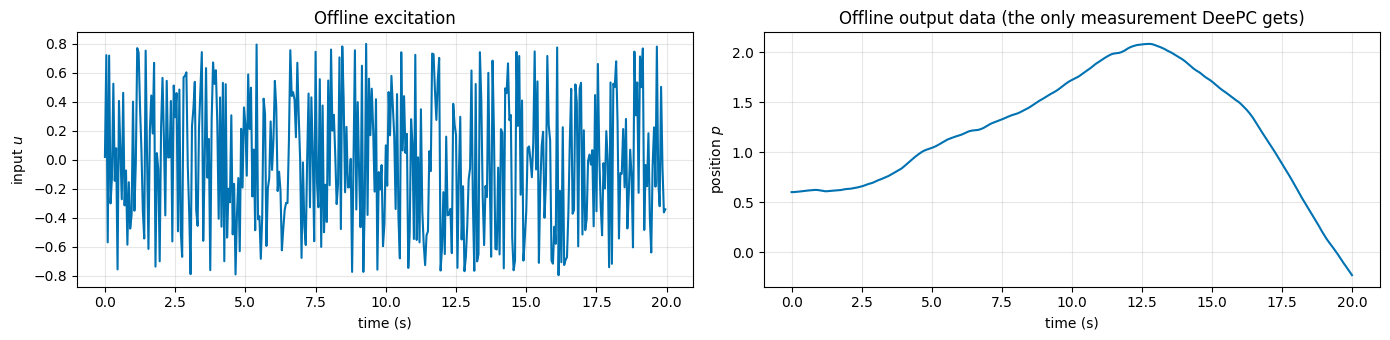

In [2]:
# Plant and task
freq = 20
dt = 1.0 / freq
t_terminal = 6.0
initial_state = np.array([-0.5, 0.0])
target_state = np.array([0.6, 0.0])
input_lbs, input_ubs = -1.0, 1.0

env_flat = Env(1, initial_state, target_state, input_lbs=input_lbs, input_ubs=input_ubs)
dyn_flat = Dynamics(env_flat)
n_states, m_inputs = 2, 1

# Controller
L = 20
T_ini = 4
Q_y = np.array([[1.0]]); R = np.array([[0.1]]); Qf_y = Q_y     # DeePC: cost on the output y = p
Q_x = np.diag([1.0, 0.0]); Qf_x = Q_x                          # MPC: the same cost on the state

# Offline data: one open-loop trajectory with random excitation, position only
T_data = 400
excitation_amplitude = 0.8
u_data, y_data = collect_deepc_data(env_flat, dyn_flat, freq=freq, n_samples=T_data,
                                    excitation_amplitude=excitation_amplitude,
                                    initial_state=target_state, seed=1, output_indices=[0])
print("u_data shape:", u_data.shape, "  y_data shape:", y_data.shape)

_, ax = plt.subplots(1, 2, figsize=(14, 3.5))
ax[0].plot(np.arange(T_data) / freq, u_data[:, 0]); ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("input $u$")
ax[0].set_title("Offline excitation")
ax[1].plot(np.arange(T_data + 1) / freq, y_data[:, 0]); ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$")
ax[1].set_title("Offline output data (the only measurement DeePC gets)")
plt.tight_layout(); plt.show()

<br>

----

### **Part 1: Willems' Fundamental Lemma and the DeePC Problem**

#### **Example 1.1: One Trajectory Spans All Trajectories**

Let $u^d_0, \ldots, u^d_{N-1}$ and $y_0, \ldots, y^d_{N-1}$ be one recorded input-output trajectory of a controllable LTI system of order $n$. Stacking windows of length $L$ column by column gives the **Hankel matrices**

$$
H_L(u^d) = \begin{bmatrix} u^d_0 & u^d_1 & \cdots & u^d_{N-L} \\ u^d_1 & u^d_2 & \cdots & u^d_{N-L+1} \\ \vdots & & & \vdots \\ u^d_{L-1} & u^d_{L} & \cdots & u^d_{N-1} \end{bmatrix}, \qquad H_L(y^d) \text{ likewise.}
$$

**Willems' fundamental lemma** states that if the input is **persistently exciting of order $L$**, meaning $H_{L}(u^d)$ has full row rank, i.e., $rank(H_{L}(u^d))=L$, then *every* input-output trajectory of length $L$ of the system can be written as

$$
\begin{bmatrix} H_L(u^d) \\ H_L(y^d) \end{bmatrix} \alpha = \begin{bmatrix} \bar{u} \\ \bar{y} \end{bmatrix} 
$$

for some coefficient vector $\alpha \in \mathbb{R}^{N-L+1}$, and conversely every such combination is a trajectory of the system. The Hankel matrix is not merely fitting the recorded experiment; its column space *is* the finite behavior of the system. 

In the following example, we check the lemma numerically on the flat car. A test trajectory of length $L = 12$ is generated from a different initial condition with a different input sequence, so it is not contained in the data. We then solve the least-squares problem for $\alpha$ and measure the relative reconstruction error, first with the persistently exciting data collected above and then with a dataset recorded under **zero input**, whose Hankel matrix is rank deficient.

random excitation:  rank(H_14(u)) = 14/14,  relative reconstruction error = 1.93e-15
zero input:         rank(H_14(u)) = 0/14,  relative reconstruction error = 1.00e+00


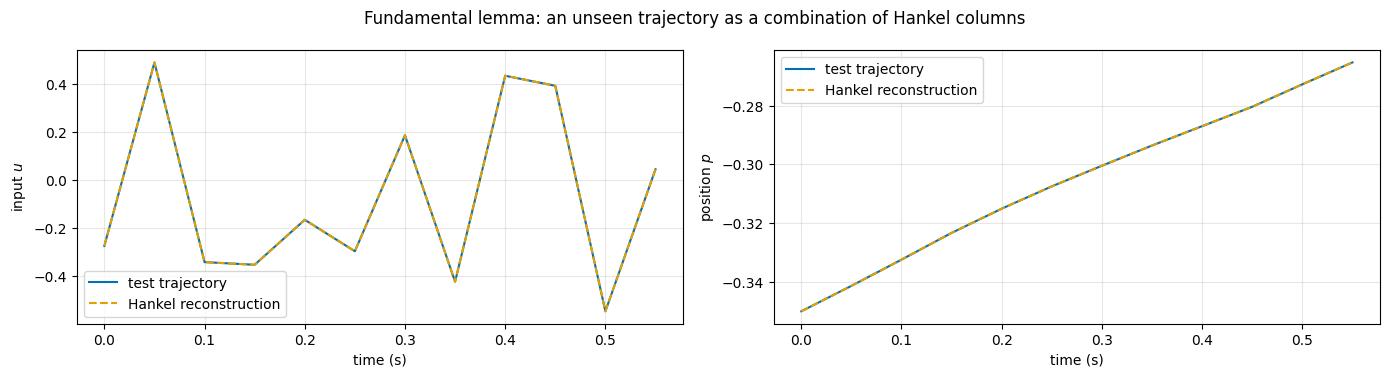

In [3]:
def rollout(dynamics, x0, u_sequence, dt):
    '''Simulate the plant open loop and return the state trajectory.'''
    x = np.asarray(x0, dtype=float).copy()
    states = [x.copy()]
    for u in np.asarray(u_sequence):
        x = dynamics.one_step_forward(x, np.asarray(u).reshape(-1), dt)
        states.append(x.copy())
    return np.asarray(states)


L_lemma = 12
pe_order = L_lemma + n_states
u_eq = np.atleast_1d(dyn_flat.get_equilibrium_input(target_state))

# An unseen test trajectory: different initial condition, different input
rng = np.random.default_rng(12)
u_test = rng.uniform(-0.55, 0.55, size=(L_lemma, 1))
y_test = rollout(dyn_flat, np.array([-0.35, 0.18]), u_test, dt)[:, [0]]   # only the position is measured

# (a) persistently exciting data
rank, required_rank = persistent_excitation_rank(u_data, pe_order, input_offset=u_eq)
_, u_rec, y_rec, rel_error = reconstruct_trajectory(u_data, y_data, u_test, y_test, length=L_lemma,
                                                    input_offset=u_eq, output_offset=np.array([target_state[0]]))
print(f"random excitation:  rank(H_{pe_order}(u)) = {rank}/{required_rank},  "
      f"relative reconstruction error = {rel_error:.2e}")

# (b) data that are not persistently exciting: constant zero input
u_bad = np.zeros((T_data, 1))
y_bad = rollout(dyn_flat, target_state, u_bad, dt)[:, [0]]
rank_bad, _ = persistent_excitation_rank(u_bad, pe_order)
_, _, _, rel_error_bad = reconstruct_trajectory(u_bad, y_bad, u_test, y_test, length=L_lemma,
                                                input_offset=np.zeros(1), output_offset=np.array([target_state[0]]))
print(f"zero input:         rank(H_{pe_order}(u)) = {rank_bad}/{required_rank},  "
      f"relative reconstruction error = {rel_error_bad:.2e}")

t_lemma = np.arange(L_lemma) / freq
_, ax = plt.subplots(1, 2, figsize=(14, 3.8))
ax[0].plot(t_lemma, u_test[:, 0], label="test trajectory")
ax[0].plot(t_lemma, u_rec[:, 0], "--", label="Hankel reconstruction")
ax[0].set_ylabel("input $u$"); ax[0].set_xlabel("time (s)"); ax[0].legend()
ax[1].plot(t_lemma, y_test[:L_lemma, 0], label="test trajectory")
ax[1].plot(t_lemma, y_rec[:, 0], "--", label="Hankel reconstruction")
ax[1].set_ylabel("position $p$"); ax[1].set_xlabel("time (s)"); ax[1].legend()
plt.suptitle("Fundamental lemma: an unseen trajectory as a combination of Hankel columns")
plt.tight_layout(); plt.show()

#### **Results Analysis**

With the randomly excited data the input Hankel matrix has full row rank and the unseen trajectory is reproduced to numerical precision, even though the test trajectory starts from a state the data never visited and uses an input sequence the data never contained. The Hankel columns span the behavior of the system, not the particular experiment. With zero input the rank collapses to the two rows contributed by the free response, and the reconstruction fails.

<br>

----

#### **Example 1.2: DeePC and Model-Based MPC Coincide on an LTI Plant**

DeePC uses the lemma as a predictor. For a prediction horizon $N$ and an initialization horizon $T_{\mathrm{ini}}$, the Hankel matrices of depth $N = L + T_{\mathrm{ini}}$ are split into a past and a future block,

$$
\begin{bmatrix} H_{L + T_{\mathrm{ini}}}(u^d) \\ H_{L + T_{\mathrm{ini}}}(y^d) \end{bmatrix} \alpha = \begin{bmatrix} \bar{u} \\ \bar{y} \end{bmatrix} 
$$

and at each control step the controller solves

$$
\begin{aligned}
\underset{\bar{u}(t),\bar{y}(t),\alpha(t)}{\text{min}} &\sum_{k=0}^{L-1}\ell(\bar{u}_k(t),\bar{y}_k(t))\\
    \text{s.t.} \quad &\begin{bmatrix}
        H_{L+T_{\mathrm{ini}}}(u^d) \\
        H_{L+T_{\mathrm{ini}}}(y^d)
    \end{bmatrix}\alpha(t) = \begin{bmatrix}
        \bar{u}(t) \\
        \bar{y}(t)
    \end{bmatrix} \\\
    &\begin{bmatrix}
        \bar{u}_{[-T_{\mathrm{ini}},-1]}(t) \\
        \bar{y}_{[-T_{\mathrm{ini}},-1]}(t)
    \end{bmatrix} = \begin{bmatrix}
        u_{[t-T_{\mathrm{ini}},t-1]} \\
        y_{[t-T_{\mathrm{ini}},t-1]}
    \end{bmatrix}  \\
    &\bar{u}_k(t)\in\mathbb{U},~\bar{y}_k(t)\in\mathbb{Y},~0\leq k \leq L-1. 
\end{aligned}
$$


The equality constraints on the past blocks pin the trajectory to the most recent $T_{\mathrm{ini}}$ measured inputs and outputs. They take over the role of the initial state in MPC: for an LTI system whose lag is at most $T_{\mathrm{ini}}$, the past window determines the internal state, so the hidden velocity is recovered from positions and inputs alone. The future blocks generate the predicted input and output in place of the model rollout. Everything else, the cost, the constraints, the receding-horizon loop and the application of the first input, is similiar to the MPC formulation.

If the lemma holds, DeePC and the model-based MPC of Chapter 5 optimize over the same set of trajectories and must produce the same closed loop. We verify this with the `LinearMPCController` of Chapter 5, which is given the exact model **and** the full state, while DeePC only ever sees positions.

Simulation finished, will start plotting
Simulation finished, will start plotting
max state difference: 1.370e-05
max input difference: 6.710e-05
mean time per step:   DeePC 7.14 ms,  MPC 1.18 ms


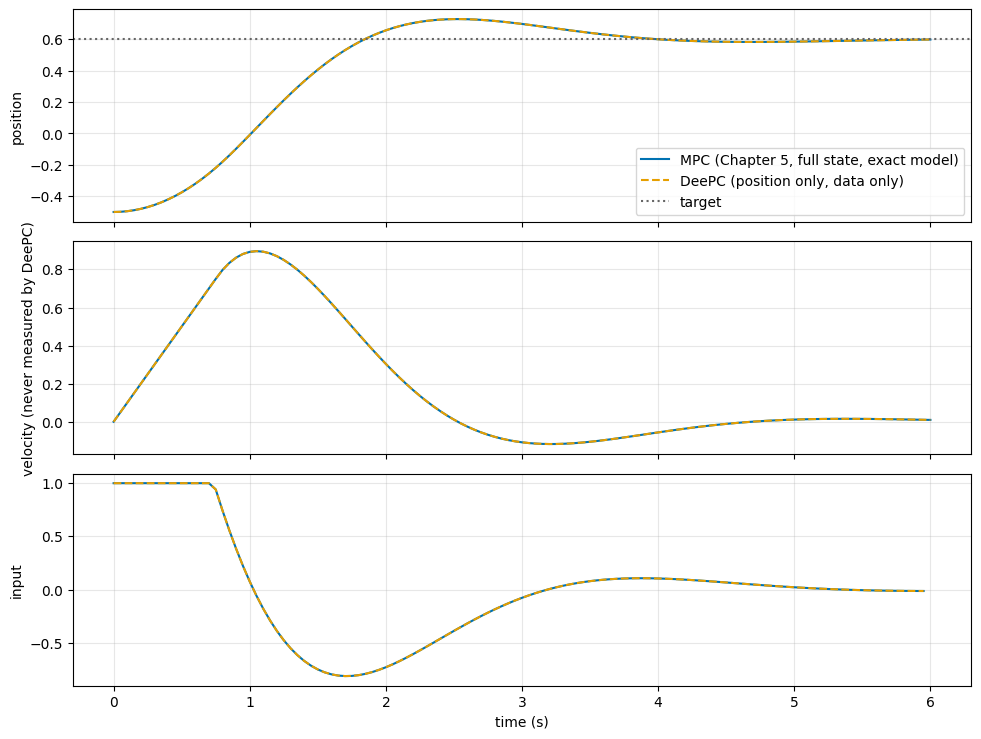

In [4]:
controller_deepc = DeePCController(env_flat, dyn_flat, u_data, y_data, Q_y, R, Qf_y, freq, L, T_ini=T_ini,
                                   lambda_g=1e-10,          # only numerical regularization for the equivalence demo
                                   output_indices=[0], history_initialization='equilibrium',
                                   name='DeePC', verbose=False)

controller_mpc = LinearMPCController(env_flat, dyn_flat, Q_x, R, Qf_x, freq, L, name='Linear_MPC', verbose=False)

# Same Simulator workflow as in Chapter 5
start = time.time()
simulator_deepc = Simulator(dyn_flat, controller_deepc, env_flat, 1/freq, t_terminal)
simulator_deepc.run_simulation()
time_deepc = time.time() - start

start = time.time()
simulator_mpc = Simulator(dyn_flat, controller_mpc, env_flat, 1/freq, t_terminal)
simulator_mpc.run_simulation()
time_mpc = time.time() - start

x_deepc, u_deepc = simulator_deepc.get_trajectories()
x_mpc, u_mpc = simulator_mpc.get_trajectories()
u_deepc = np.asarray(u_deepc).reshape(-1, m_inputs); u_mpc = np.asarray(u_mpc).reshape(-1, m_inputs)

print(f"max state difference: {np.max(np.linalg.norm(x_deepc - x_mpc, axis=1)):.3e}")
print(f"max input difference: {np.max(np.linalg.norm(u_deepc - u_mpc, axis=1)):.3e}")
print(f"mean time per step:   DeePC {time_deepc/(freq*t_terminal)*1e3:.2f} ms,  MPC {time_mpc/(freq*t_terminal)*1e3:.2f} ms")

t_x = np.arange(x_deepc.shape[0]) / freq
t_u = np.arange(u_deepc.shape[0]) / freq
_, ax = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
ax[0].plot(t_x, x_mpc[:, 0], label="MPC (Chapter 5, full state, exact model)")
ax[0].plot(t_x, x_deepc[:, 0], "--", label="DeePC (position only, data only)")
ax[0].axhline(target_state[0], color="0.4", linestyle=":", label="target"); ax[0].set_ylabel("position"); ax[0].legend()
ax[1].plot(t_x, x_mpc[:, 1]); ax[1].plot(t_x, x_deepc[:, 1], "--"); ax[1].set_ylabel("velocity (never measured by DeePC)")
ax[2].plot(t_u, u_mpc[:, 0]); ax[2].plot(t_u, u_deepc[:, 0], "--"); ax[2].set_ylabel("input"); ax[2].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

#### **Results Analysis**

The two closed loops are indistinguishable: state and input differ by about $10^{-5}$, the level of the solver tolerances (acados for the MPC, OSQP for DeePC). DeePC replaces the model-based trajectory generator, not the predictive-control idea. The objective, the constraints, the receding-horizon loop and the first-input implementation are the same, and for a deterministic LTI system with sufficiently rich data the Hankel matrix and the $(A, B)$ model describe the same finite behavior.

Note also what DeePC was *not* given. The MPC is handed the velocity at every step; DeePC only sees positions, and recovers the velocity implicitly from the last $T_{\mathrm{ini}}$ positions and inputs. For the double integrator two past samples would suffice ($T_{\mathrm{ini}} \ge$ n_x $= 2$); we use $T_{\mathrm{ini}} = 4$ throughout, which does not change the result here and becomes helpful once the data are not exactly consistent with an LTI behavior.

<br>

----

### **Part 2: How Much Data Does DeePC Need?**

#### **Example 2.1: Two Data-Length Bounds on Flat Terrain**

What the predictor needs is that the columns of the Hankel matrix span **every** input-output trajectory of length $L + T_{\mathrm{ini}}$, which is the length of the decision variables $\bar u(t), \bar y(t)$ in the DeePC problem. Each column is by construction such a trajectory, so the span is always *contained* in that set. Only the dimension has to match, and the literature offers two conditions for it:

**(a) Persistency of excitation, sufficient condition.** If the system is controllable and $u^d$ is persistently exciting of order $L + T_{\mathrm{ini}} + n_x$,

$$
\operatorname{rank} H_{L+T_{\mathrm{ini}}+n_x}\big(u^d\big) \;=\; n_u\,(L + T_{\mathrm{ini}} + n_x) \;=\; 26 \qquad \text{(full row rank)},
$$

then the span is correct. This is a condition on the **input alone**: it can be imposed when the experiment is designed, without knowing the system, and it certifies the span for *every* system of order at most $n_x$. Since a Hankel matrix of depth $L+T_{\mathrm{ini}}+n_x$ built from $N$ samples has $N - (L+T_{\mathrm{ini}}+n_x) + 1$ columns, full row rank requires

$$
N \;\ge\; (n_u+1)\,(L + T_{\mathrm{ini}} + n_x) - 1 \;=\; 51 .
$$

**(b) Generalized persistency of excitation, necessary and sufficient.** The span is correct **if and only if**

$$
\operatorname{rank}\begin{bmatrix} H_{L+T_{\mathrm{ini}}}(u^d) \\[2pt] H_{L+T_{\mathrm{ini}}}(y^d) \end{bmatrix} \;=\; n_u\,(L + T_{\mathrm{ini}}) + n_x \;=\; 26 ,
$$

which is the rank condition of the tutorial paper, Eq. (17). This is a condition on the **measured data**, input and output together: it depends on the system and can only be evaluated once the data are collected.

**References.** J. C. Willems, P. Rapisarda, I. Markovsky and B. L. M. De Moor, *A note on persistency of excitation*, Systems & Control Letters, 54(4):325-329, 2005, for (a); I. Markovsky and F. Dörfler, *Identifiability in the behavioral setting*, IEEE TAC, 68(3):1667-1677, 2023, for (b). The column counts are elementary consequences of the two rank conditions.


Next, we run DeePC with the first $N$ samples of the recorded trajectory, for $N$ from `40` to `66`, report both ranks, and compare each closed loop with the MPC that uses the exact model. The deviation measure is the root-mean-square position deviation over the whole run,

$$
d = \Bigl(\tfrac{1}{K+1}\sum_{k=0}^{K} \bigl(p_k^{\mathrm{DeePC}} - p_k^{\mathrm{MPC}}\bigr)^2\Bigr)^{1/2},
$$

which is zero if and only if the two closed loops coincide. Below the bounds the controller's own persistency check would reject the data; we switch it off (`enforce_pe_check=False`) to see what happens: the history constraints become infeasible at every step, and the fallback input $u = 0$ keeps the car where it is. The reference MPC is written in the same position-only form as DeePC (an exact ARX model of the double integrator, `ARXPredictiveController`), so that the comparison isolates the data representation and nothing else.

In [5]:
def run_closed_loop(controller, plant, env_run, t_end=t_terminal):
    '''Closed loop with a fallback input u = 0 if a QP is infeasible. Returns states, inputs, #failures.'''
    x = env_run.init_state.copy()
    states, inputs, failures = [x.copy()], [], 0
    for k in range(int(freq * t_end)):
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                u = controller.compute_action(x, k)
            u = u[0] if isinstance(u, tuple) else u
        except RuntimeError:
            failures += 1
            u = np.zeros(1)
            if isinstance(controller, DeePCController):
                controller.initialize_history(x, mode='equilibrium')
        u = np.clip(np.asarray(u, dtype=float).reshape(-1), input_lbs, input_ubs)
        x = plant.one_step_forward(x, u, dt)
        states.append(x.copy()); inputs.append(u.copy())
    return np.asarray(states), np.asarray(inputs), failures


def rms_deviation(X, X_ref):
    return float(np.sqrt(np.mean((X[:, 0] - X_ref[:, 0])**2)))


t_x = np.arange(int(freq * t_terminal) + 1) * dt
a_true, b_true = true_arx_double_integrator(dt)
N_BOUND = (m_inputs + 1) * (L + T_ini + n_states) - 1      # (a) PE of order L + T_ini + n_x: sufficient
N_BOUND_GPE = (m_inputs + 1) * (L + T_ini) + n_states - 1  # (b) generalized PE, Eq. (17): necessary and sufficient

# Reference: MPC with the exact (ARX) model of the flat plant
X_mpc_flat, _, _ = run_closed_loop(ARXPredictiveController(env_flat, dyn_flat, a_true, b_true, Q_y, R, Qf_y, freq, L),
                                   dyn_flat, env_flat)

def deepc_flat(N):
    return DeePCController(env_flat, dyn_flat, u_data[:N], y_data[:N + 1], Q_y, R, Qf_y, freq, L, T_ini=T_ini,
                           lambda_g=1e-10, output_indices=[0], history_initialization='equilibrium',
                           enforce_pe_check=False, verbose=False)

def evaluate_flat(N):
    c = deepc_flat(N)
    X, _, fails = run_closed_loop(c, dyn_flat, env_flat)
    # (a) classical PE of the input, (b) generalized PE of the input-output data
    return dict(N=N, pe_cols=c.pe_columns, pe_rank=c.pe_rank, pe_need=c.pe_required_rank,
                gpe_cols=c.gpe_columns, gpe_rank=c.gpe_rank, gpe_need=c.gpe_required_rank,
                dev=rms_deviation(X, X_mpc_flat), fails=fails), X

N_SWEEP = list(range(40, 67))
N_HIGHLIGHT = {"below PE bound": 48, "at PE bound": 51, "above PE bound": 60}
sweep = [evaluate_flat(N)[0] for N in N_SWEEP]
highlight = {label: evaluate_flat(N) for label, N in N_HIGHLIGHT.items()}

print(f"(a) PE of order L+T_ini+n_x  (sufficient):  rank H_{L+T_ini+n_states}(u) = {m_inputs*(L+T_ini+n_states)}             ->  N >= {N_BOUND}")
print(f"(b) generalized PE  (nec. and sufficient):  rank [H_{L+T_ini}(u); H_{L+T_ini}(y)] = {m_inputs*(L+T_ini)+n_states}  ->  N >= {N_BOUND_GPE}\n")
print(f"{'':>5} | {'(a) PE of only input':^24} | {'(b) Generalized PE':^24} |")
print(f"{'N':>5} | {'cols':>6} {'rank':>6} {'need':>6} {'ok':>3} | {'cols':>6} {'rank':>6} {'need':>6} {'ok':>3} | {'RMS dev. (m)':>13} {'infeasible':>11}")
for r in sweep:
    print(f"{r['N']:5d} | {max(r['pe_cols'],0):6d} {r['pe_rank']:6d} {r['pe_need']:6d} {'yes' if r['pe_rank']==r['pe_need'] else 'no':>3} |"
          f" {r['gpe_cols']:6d} {r['gpe_rank']:6d} {r['gpe_need']:6d} {'yes' if r['gpe_rank']==r['gpe_need'] else 'no':>3} |"
          f" {r['dev']:13.2e} {r['fails']:11d}")

(a) PE of order L+T_ini+n_x  (sufficient):  rank H_26(u) = 26             ->  N >= 51
(b) generalized PE  (nec. and sufficient):  rank [H_24(u); H_24(y)] = 26  ->  N >= 49

      |   (a) PE of only input   |    (b) Generalized PE    |
    N |   cols   rank   need  ok |   cols   rank   need  ok |  RMS dev. (m)  infeasible
   40 |     15     15     26  no |     17     17     26  no |      9.99e-01         120
   41 |     16     16     26  no |     18     18     26  no |      9.99e-01         120
   42 |     17     17     26  no |     19     19     26  no |      9.99e-01         120
   43 |     18     18     26  no |     20     20     26  no |      9.99e-01         120
   44 |     19     19     26  no |     21     21     26  no |      9.99e-01         120
   45 |     20     20     26  no |     22     22     26  no |      9.99e-01         120
   46 |     21     21     26  no |     23     23     26  no |      9.99e-01         120
   47 |     22     22     26  no |     24     24     26  no |

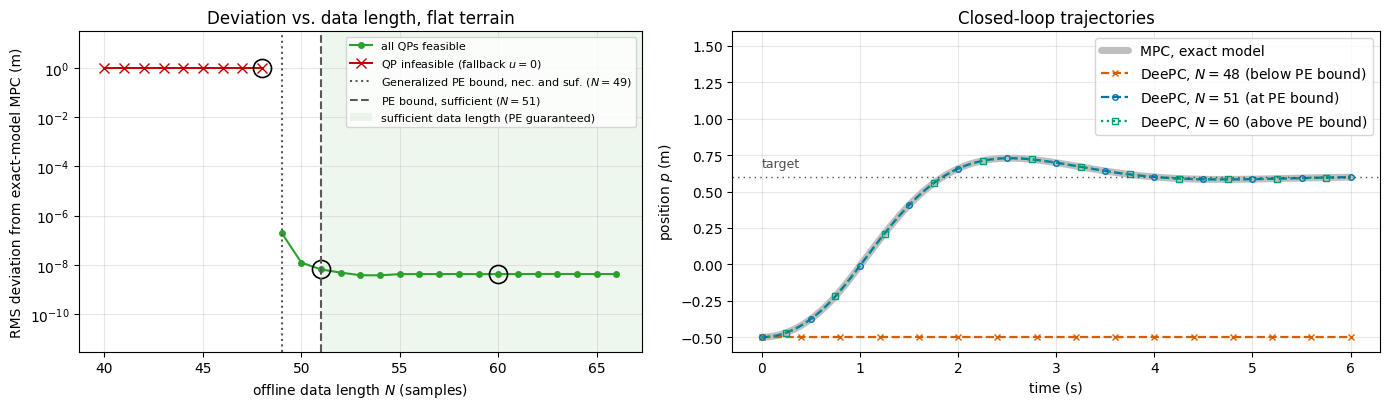

In [6]:
Ns = np.array([r['N'] for r in sweep]); devs = np.array([r['dev'] for r in sweep]); fails = np.array([r['fails'] for r in sweep])
C_LEFT, C_INFEAS, C_BOUND = "#2CA02C", "#C00000", "0.35"

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), width_ratios=[1, 1.15])
ok = fails == 0
ax[0].semilogy(Ns[ok], np.maximum(devs[ok], 1e-12), marker="o", ms=4, color=C_LEFT, label="all QPs feasible")
ax[0].semilogy(Ns[~ok], devs[~ok], marker="x", ms=7, ls="-", lw=1.4, color=C_INFEAS, label="QP infeasible (fallback $u=0$)")
for label, (row, _) in highlight.items():
    ax[0].plot(row['N'], max(row['dev'], 1e-12), marker="o", ms=13, mfc="none", mec="k", mew=1.2, ls="none")
ax[0].axvline(N_BOUND_GPE, color=C_BOUND, ls=":", lw=1.5, label=f"Generalized PE bound, nec. and suf. ($N={N_BOUND_GPE}$)")
ax[0].axvline(N_BOUND, color=C_BOUND, ls="--", lw=1.5, label=f"PE bound, sufficient ($N={N_BOUND}$)")
ax[0].set_ylim(3e-12, 30)
x_left, x_right = ax[0].get_xlim()
ax[0].axvspan(N_BOUND, x_right, color=C_LEFT, alpha=0.08, lw=0, zorder=0, label="sufficient data length (PE guaranteed)")
ax[0].set_xlim(x_left, x_right)
ax[0].set_xlabel("offline data length $N$ (samples)"); ax[0].set_ylabel("RMS deviation from exact-model MPC (m)")
ax[0].set_title("Deviation vs. data length, flat terrain"); ax[0].legend(loc="best", fontsize=8)

ax[1].plot(t_x, X_mpc_flat[:, 0], color="0.75", lw=5, solid_capstyle="round", label="MPC, exact model")
styles = [dict(color=OKABE_ITO[3], ls="--", marker="x", markevery=8, ms=5),
          dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), ms=4, mfc="none"),
          dict(color=OKABE_ITO[2], ls=":", marker="s", markevery=(5, 10), ms=4, mfc="none")]
for j, (label, N) in enumerate(N_HIGHLIGHT.items()):
    ax[1].plot(t_x, highlight[label][1][:, 0], lw=1.6, label=f"DeePC, $N={N}$ ({label})", **styles[j])
ax[1].axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] + 0.05, "target", ha="left", va="bottom", fontsize=9, color="0.3")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m)"); ax[1].set_title("Closed-loop trajectories"); ax[1].legend(loc="best")
ax[1].set_ylim(-0.6, 1.6)
plt.tight_layout(); plt.show()

#### **Results Analysis**

**Below the bounds nothing works.** For $N \le 48$ neither condition is met: every QP is infeasible, the fallback input keeps the car where it started, and the deviation is `1.0` m, the distance to where the MPC goes.

**The *generalized* persistency of excitation (PE) condition is what decides, but it can only be checked with the input-output data in hand.** The closed loop starts working exactly at $N = 49$, where the stacked Hankel first reaches rank `26`. Being necessary *and* sufficient, the price is that it involves the measured output $y^d$, so it can only be evaluated after the data-collection pipeline has been run.

**The persistency of excitation (PE) condition is the design condition, but sometime it is conservative.** It uses only $n_u$, $L$, $T_{\mathrm{ini}}$ and an upper bound on $n_x$, so it can be imposed *before* the experiment, without knowing the system. Being sufficient but not necessary, it asks for more samples than the generalized PE condition: the judgement on this criteria still fails at $N = 49$ and $N = 50$, where the loop already works.

**Beyond the PE condition, more data change nothing.** For an exact LTI system the data-driven predictor is then exact, so the closed loop *is* the exact-model MPC and additional samples will not improve the performance. The sweep shows exactly this: the deviation drops below `1e-6` m as soon as $N = 49$, and the remaining decrease to about `4e-9` m is truncation and solver error, not a change in control performance. The only thing that grows with $N$ is the size of the quadratic program.

<br>

----

### **Part 3: Beyond the LTI Assumption: Regularization**

The fundamental lemma is exact for controllable LTI systems. The bumpy terrain $h(p) = k\cos(18p)$ is nonlinear because the slope depends on the position, and relative to the flat model it acts as an unmodeled, state-dependent perturbation. The quick check below repeats the reconstruction of Example 1.1 with the **flat** Hankel matrix for test trajectories generated on terrains of increasing bump amplitude $k$. At $k = 0$ the reconstruction is exact; as $k$ grows the true trajectories leave the span of the flat data.

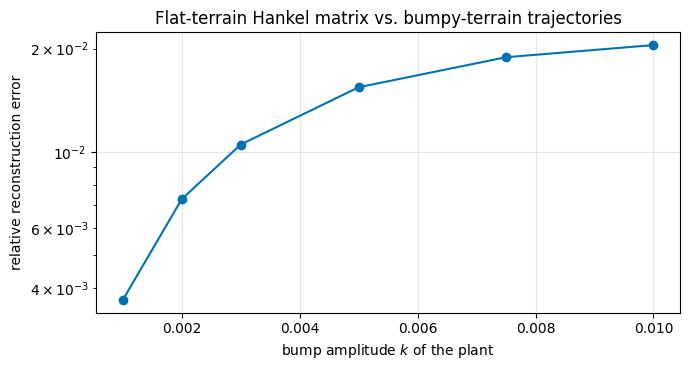

In [7]:
L_check = 16
rng = np.random.default_rng(30)
u_check = rng.uniform(-0.45, 0.45, size=(L_check, 1))
bump_amplitudes = np.array([0.001, 0.002, 0.003, 0.005, 0.0075, 0.01])
reconstruction_errors = []
for bump in bump_amplitudes:
    dyn_b_check = Dynamics(Env(3, initial_state, target_state, param=float(bump)))
    y_check = rollout(dyn_b_check, np.array([-0.35, 0.18]), u_check, dt)[:, [0]]
    _, _, _, err = reconstruct_trajectory(u_data, y_data, u_check, y_check, length=L_check,
                                          input_offset=np.zeros(1), output_offset=np.array([target_state[0]]))
    reconstruction_errors.append(err)

plt.figure(figsize=(7, 3.8))
plt.semilogy(bump_amplitudes, np.maximum(reconstruction_errors, 1e-16), marker="o")
plt.xlabel("bump amplitude $k$ of the plant"); plt.ylabel("relative reconstruction error")
plt.title("Flat-terrain Hankel matrix vs. bumpy-terrain trajectories")
plt.tight_layout(); plt.show()

Once the data are not consistent with an LTI behavior, whether because the plant is nonlinear or because the measurements are noisy, two things go wrong with the deterministic formulation of Example 1.2. The hard constraint on initial output trajectory can become **infeasible**, since the measured history is no longer in the span of the data, and when the data themselves are perturbed the Hankel matrix becomes **full rank**, so the equality can match *any* history and the coefficient $\alpha$ carries no information about the plant. The standard remedy is the **regularized DeePC problem**


$$
\begin{aligned}
\underset{\bar{u}(t),\bar{y}(t),\alpha(t),\sigma(t)}{\text{min}} &\sum_{k=0}^{L-1}\ell(\bar{u}_k(t),\bar{y}_k(t)) + \lambda_{\sigma}||\sigma(t)||^2_2 + \lambda_{\alpha}||\alpha(t)||^2_2\\
    \text{s.t.} \quad &\begin{bmatrix}
        H_{L+T_{\mathrm{ini}}}(u^d) \\
        H_{L+T_{\mathrm{ini}}}(y^d)
    \end{bmatrix}\alpha(t) = \begin{bmatrix}
        \bar{u}(t) \\
        \bar{y}(t) + \sigma(t)
    \end{bmatrix} \\\
    &\begin{bmatrix}
        \bar{u}_{[-T_{\mathrm{ini}},-1]}(t) \\
        \bar{y}_{[-T_{\mathrm{ini}},-1]}(t)
    \end{bmatrix} = \begin{bmatrix}
        u_{[t-T_{\mathrm{ini}},t-1]} \\
        y_{[t-T_{\mathrm{ini}},t-1]}
    \end{bmatrix}  \\
    &\bar{u}_k(t)\in\mathbb{U},~\bar{y}_k(t)\in\mathbb{Y},~0\leq k \leq L-1. 
\end{aligned}
$$

where the slack $\sigma(t)$ lets the output history be *fitted* rather than matched, with $\lambda_{\sigma}$ setting how strongly the measured history is trusted, and $\lambda_{\alpha}$ penalizes the size of $\alpha$ to prevent it from fitting noise. Both terms keep the problem a convex QP. Regularization does not make the nonlinear plant LTI; it makes the data-driven optimization well posed when the data and the measurements are not exactly consistent with one behavior.

#### **The Scenario of Chapter 6.3**

From here on every experiment runs on the **terrain and data of Chapter 6.3**, so that the results can be read next to the learning-based MPC of that chapter: the bump amplitude is $k = 0.01$, and the learning data carry Gaussian measurement noise with standard deviation $\sigma = 5\cdot10^{-3}$ m. Three consequences for the setup:

- The terrain force reaches `1.7` m/s², more than the input bound $|u| \le 1$ of Parts 1 and 2 allows. We therefore drop the **input constraint** in this and the next part; there are no state constraints either.

- The cost is $\ell(u, y) = (y - p^s)^2 + 0.02\,u^2$. With the input weight `0.02` of Parts 1 and 2 even the MPC with the true model prefers to rest on a slope short of the target within its 1 s horizon, and a reference that does not reach the target would be of little use.

- The data are recorded **on the bumpy plant**, in closed loop along the task: a stabilizing feedback drives the car from $p = -0.5$ towards the target while random excitation is added, so the record covers the terrain the task crosses, and the recorded positions are corrupted by noise. Open-loop excitation would let the car roll away on the slopes.

The reference for everything that follows is the nonlinear MPC with the true bumpy model (`NonlinearMPCOracle`, CasADi/ipopt, the same cost written on the state), and the MPC with the flat-terrain model marks what physics without terrain knowledge achieves.

In [8]:
# ---- Scenario of Chapter 6.3: terrain, noise, cost -----------------------------------------------
K_TERRAIN_B = 0.01
SIGMA_B = 5e-3
R_b = np.array([[0.02]])                                   # l(u, y) = (y - p_s)^2 + 0.02 u^2
Q_b_y, Qf_b_y, Q_b_x, Qf_b_x = Q_y, Qf_y, Q_x, Qf_x        # position weight 1, as in Parts 1 and 2

env_b = Env(3, initial_state, target_state, param=K_TERRAIN_B)          # no input or state constraints
dyn_b = Dynamics(env_b)
u_eq_b = float(np.atleast_1d(dyn_b.get_equilibrium_input(target_state))[0])
theta_max_b = np.arctan(18 * K_TERRAIN_B)
print(f"k = {K_TERRAIN_B}: peak terrain force {9.81 * np.sin(theta_max_b) * np.cos(theta_max_b):.2f} m/s^2, "
      f"equilibrium input at the target {u_eq_b:.3f}")

# Stabilizing feedback for closed-loop data collection: LQR on the flat model for this cost
A_d, B_d = dyn_flat.get_linearized_AB_discrete(target_state, np.zeros(1), dt)
P_b = scipy.linalg.solve_discrete_are(A_d, B_d, Q_b_x, R_b)
K_b = np.linalg.solve(R_b + B_d.T @ P_b @ B_d, B_d.T @ P_b @ A_d)

def bumpy_data(N, seed, sigma=SIGMA_B, start=None):
    '''One closed-loop record (u, p) on the bumpy plant, positions corrupted by N(0, sigma^2).
    By default the record starts at the initial state and covers the task; start=target_state gives a record around the target.'''
    u_d, y_d = collect_deepc_data_closed_loop(env_b, dyn_b, freq=freq, n_samples=N, feedback_gain=K_b, excitation_amplitude=1.0,
                                              initial_state=initial_state if start is None else start, seed=100 + seed, output_indices=[0])
    rng = np.random.default_rng(1000 + seed)
    return u_d, y_d + rng.normal(0.0, sigma, y_d.shape)

def data_energy(u_d, y_d):
    return float(np.sum((u_d - u_eq_b)**2) + np.sum((y_d - target_state[0])**2))

def run_cl_b(controller, t_end=t_terminal):
    '''Closed loop against the true bumpy plant, exact online measurements, fallback u_eq if a solve fails.'''
    x = env_b.init_state.copy()
    states, inputs, failures = [x.copy()], [], 0
    for k in range(int(freq * t_end)):
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                out = controller.compute_action(x, k)
            u = out[0] if isinstance(out, tuple) else out
        except RuntimeError:
            failures += 1; u = np.array([u_eq_b])
            if isinstance(controller, DeePCController):
                controller.initialize_history(x, mode='equilibrium')
        u = np.asarray(u, dtype=float).reshape(-1)
        x = dyn_b.one_step_forward(x, u, dt)
        states.append(x.copy()); inputs.append(u.copy())
    return np.asarray(states), np.asarray(inputs), failures

def cl_cost_b(states, inputs):
    dp = states[:, 0] - target_state[0]
    du = inputs[:, 0] - u_eq_b
    return float(np.sum(Q_b_y[0, 0] * dp[:-1]**2 + R_b[0, 0] * du**2) + Qf_b_y[0, 0] * dp[-1]**2)

def make_deepc_b(u_d, y_d, lambda_g, lambda_y):
    return DeePCController(env_b, dyn_b, u_d, y_d, Q_b_y, R_b, Qf_b_y, freq, L, T_ini=T_ini, lambda_g=lambda_g, lambda_y=lambda_y,
                           output_indices=[0], history_initialization='equilibrium', enforce_pe_check=False, verbose=False)

# References, computed once
X_true, U_true, _ = run_cl_b(NonlinearMPCOracle(env_b, dyn_b, Q_b_x, R_b, Qf_b_x, freq, L))
X_flatm, U_flatm, _ = run_cl_b(ARXPredictiveController(env_b, dyn_b, a_true, b_true, Q_b_y, R_b, Qf_b_y, freq, L, name="flat"))
J_true_b, J_flat_b = cl_cost_b(X_true, U_true), cl_cost_b(X_flatm, U_flatm)
valleys = (2 * np.arange(-2, 8) + 1) * np.pi / 18
valley_p = float(valleys[valleys > target_state[0]][0])                 # first terrain valley beyond the target
print(f"true-model MPC:  cost {J_true_b:.2f}, final p {X_true[-1, 0]:.3f}")
print(f"flat-model MPC:  cost {J_flat_b:.2f}, final p {X_flatm[-1, 0]:.3f}, RMS deviation from the true-model MPC {rms_deviation(X_flatm, X_true):.3f} m "
      f"(terrain valley beyond the target at p = {valley_p:.3f})")

k = 0.01: peak terrain force 1.71 m/s^2, equilibrium input at the target 1.706
true-model MPC:  cost 15.27, final p 0.600
flat-model MPC:  cost 28.35, final p 0.876, RMS deviation from the true-model MPC 0.257 m (terrain valley beyond the target at p = 0.873)


#### **Example 3.1: What Regularization Buys and Costs**

We take one record of `800` noisy samples and sweep the two regularization weights: $\lambda_{\alpha}$ over twelve decades for three values of $\lambda_{\sigma}$, from an almost unconstrained fit of the measured history ($\lambda_{\sigma} = 10$) to a very tight one ($\lambda_{\sigma} = 10^6$). The measure is the RMS position deviation from the true-model MPC, so that a controller that behaves like the flat-terrain model shows up at the deviation of that model, and a controller that reaches the target shows up near zero.

In [9]:
LAMBDA_alpha_GRID = [0.001, 0.1, 10.0, 1e3, 1e5, 1e7, 1e9]
LAMBDA_sigma_GRID = [1e1, 1e3, 1e6]
N_DATA_31 = 800
u_800, y_800 = bumpy_data(N_DATA_31, seed=0)

dev_grid = np.zeros((len(LAMBDA_sigma_GRID), len(LAMBDA_alpha_GRID)))
final_grid = np.zeros_like(dev_grid)
for iy, ly in enumerate(LAMBDA_sigma_GRID):
    for ig, lg in enumerate(LAMBDA_alpha_GRID):
        X, _, _ = run_cl_b(make_deepc_b(u_800, y_800, lg, ly))
        dev_grid[iy, ig] = rms_deviation(X, X_true); final_grid[iy, ig] = X[-1, 0]

print(f"RMS deviation from the true-model MPC (m)  [final position in brackets];  flat-model MPC: {rms_deviation(X_flatm, X_true):.3f} m")
print(f"{'lambda_sigma / lambda_alpha':>20} " + " ".join(f"{lg:>14.0e}" for lg in LAMBDA_alpha_GRID))
for iy, ly in enumerate(LAMBDA_sigma_GRID):
    print(f"{ly:>20.0e} " + " ".join((f"{dev_grid[iy, ig]:6.3f} [{final_grid[iy, ig]:5.2f}]" if dev_grid[iy, ig] < 50 else f"{'diverged':>14}") for ig in range(len(LAMBDA_sigma_GRID))))

RMS deviation from the true-model MPC (m)  [final position in brackets];  flat-model MPC: 0.257 m
lambda_sigma / lambda_alpha          1e-03          1e-01          1e+01          1e+03          1e+05          1e+07          1e+09
               1e+01 10.406 [25.36]  9.642 [23.42]  1.015 [-0.48]
               1e+03 10.402 [25.34]  8.901 [20.28]  0.820 [ 1.53]
               1e+06 10.754 [27.48]  8.816 [19.95]  0.801 [ 1.53]


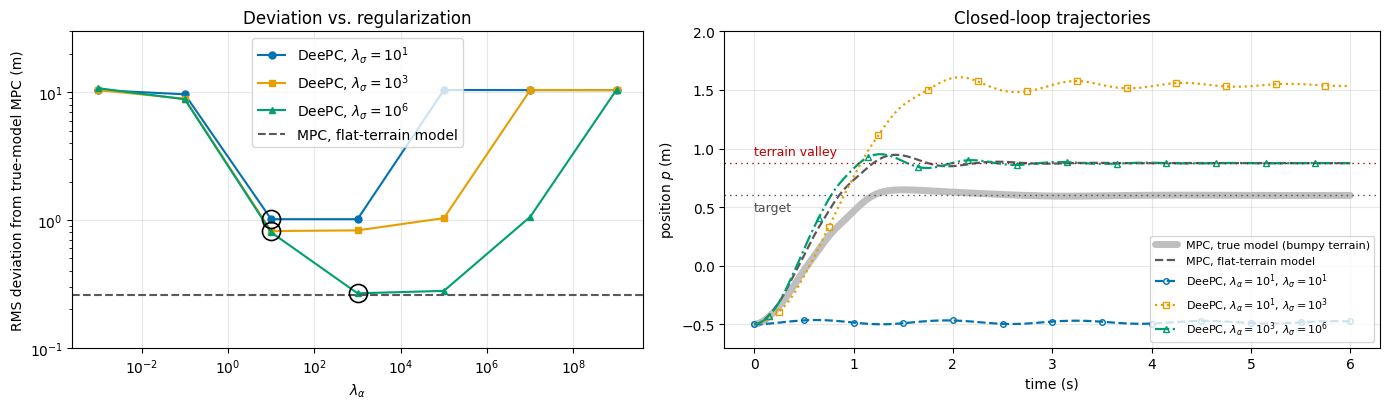

In [10]:
TRAJECTORY_SETTINGS = [(1e1, 1e1), (1e1, 1e3), (1e3, 1e6)]         # (lambda_a, lambda_sigma) shown on the right
traj_bumpy = {(la, lsigma): run_cl_b(make_deepc_b(u_800, y_800, la, lsigma))[0] for la, lsigma in TRAJECTORY_SETTINGS}

# Start Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), width_ratios=[1, 1.15])
markers = ["o", "s", "^"]
for isigma, lsigma in enumerate(LAMBDA_sigma_GRID):
    ax[0].loglog(LAMBDA_alpha_GRID, np.minimum(dev_grid[isigma], 30), marker=markers[isigma], ms=5, color=OKABE_ITO[isigma],
                 label=f"DeePC, $\\lambda_\\sigma = 10^{{{int(np.log10(lsigma))}}}$")
ax[0].axhline(rms_deviation(X_flatm, X_true), color="0.35", ls="--", lw=1.5, label="MPC, flat-terrain model")
for lalpha, lsigma in TRAJECTORY_SETTINGS:
    ax[0].plot(lalpha, min(dev_grid[LAMBDA_sigma_GRID.index(lsigma), LAMBDA_alpha_GRID.index(lalpha)], 30), marker="o", ms=13, mfc="none", mec="k", mew=1.2, ls="none")
ax[0].set_ylim(0.1, 30)
ax[0].set_xlabel(r"$\lambda_\alpha$"); ax[0].set_ylabel("RMS deviation from true-model MPC (m)")
ax[0].set_title(f"Deviation vs. regularization"); ax[0].legend(loc="best")

ax[1].plot(t_x, X_true[:, 0], color="0.75", lw=5, solid_capstyle="round", label="MPC, true model (bumpy terrain)")
ax[1].plot(t_x, X_flatm[:, 0], color="0.35", lw=1.6, ls="--", label="MPC, flat-terrain model")
line_styles = [dict(ls="--", marker="o", markevery=(0, 10), ms=4, mfc="none"),
               dict(ls=":", marker="s", markevery=(5, 10), ms=4, mfc="none"),
               dict(ls="-.", marker="^", markevery=(3, 10), ms=5, mfc="none")]
for j, (lalpha, lsigma) in enumerate(TRAJECTORY_SETTINGS):
    ax[1].plot(t_x, traj_bumpy[(lalpha, lsigma)][:, 0], lw=1.6, color=OKABE_ITO[LAMBDA_sigma_GRID.index(lsigma)],
               label=f"DeePC, $\\lambda_\\alpha=10^{{{int(np.log10(lalpha))}}}$, $\\lambda_\\sigma=10^{{{int(np.log10(lsigma))}}}$", **line_styles[j])
ax[1].axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] - 0.05, "target", ha="left", va="top", fontsize=9, color="0.3")
ax[1].axhline(valley_p, color="#C00000", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], valley_p + 0.05, "terrain valley", ha="left", va="bottom", fontsize=9, color="#C00000")
ax[1].set_ylim(-0.7, 2.0)
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m)"); ax[1].set_title("Closed-loop trajectories"); ax[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

#### **Results Analysis**

**The weights decide whether the regularization works at all.** Of the 21 combinations in the sweep only two are usable, both at the tight history fit $\lambda_{\sigma} = 10^6$, with $\lambda_{\alpha} = 10^3$ or $10^5$. Too small a $\lambda_{\alpha}$ lets the prediction follow the terrain-induced inconsistency in the data and the car runs away (deviation `9` to `11` m, ending `20` to `27` m past the target); too large a $\lambda_{\alpha}$ pulls the coefficients towards zero until the measured history is no longer reproduced. With a loose history fit ($\lambda_{\sigma} = 10$ or $10^3$) the best outcomes are a car that does not move ($p = -0.48$) or one that overshoots into the second valley ($p = 1.53$). The three circled cases in the figure are these three outcomes. The weights therefore have to be tuned deliberately and re-checked whenever the record changes.

**At the best setting DeePC performs like the MPC with the flat-terrain model.** It comes to rest in the first terrain valley beyond the target, at $p = 0.88$ against the `0.876` of that model, with an RMS deviation of `0.27` m from the true-model MPC against `0.26` m. We take $\lambda_{\alpha} = 10^3$ and $\lambda_{\sigma} = 10^6$ into the rest of the chapter.

<br>

----

#### **Example 3.2: Data Length on Bumpy Terrain**

On the LTI plant of Example 2.1 the data-length requirement from PE condition provides a sufficient bound, above which the predictor is exact and more samples brings no benifit. This example asks what's the case for a nonlinear model with output disturbances. Everything is as in Example 3.1, the regularization weights are selected as $\lambda_{\alpha} = 10^3$ and $\lambda_{\sigma} = 10^6$. Only the record length $N$ varies, such that we can investigate what's the impact of the progressively longer offline trajectory.

The Hankel matrix is full rank at any length, so the persistency check is switched off and $N \ge 51$ only marks where the QP can be posed. Every $N$ is repeated for ten independent records, and those whose closed loop runs away enter the statistics at a cap of `5` m. The figure shows the median and the 10-90% range, on the right the best record of each highlighted $N$, and the table the final position error; the reference is again the nonlinear MPC with the true model.

In [11]:
LAMBDA_alpha_31, LAMBDA_sigma_31 = 1e3, 1e6 
N_SWEEP_31 = [51, 75, 100, 150, 200, 300, 400, 600, 800]
N_SEEDS_31 = 10
DEV_CAP = 5.0                                              # deviations above this are reported as unstable and drawn at the cap

def deepc_bumpy_data(N, seed):
    '''DeePC from a record of N samples collected around the target, with the weights selected in Example 3.1.'''
    u_d, y_d = bumpy_data(N, seed, start=target_state)
    return make_deepc_b(u_d, y_d, LAMBDA_alpha_31, LAMBDA_sigma_31)

dev_br = np.zeros((len(N_SWEEP_31), N_SEEDS_31))          # RMS deviation from the true-model MPC
err_br = np.zeros_like(dev_br)                             # final position error
for i, N in enumerate(N_SWEEP_31):
    for sd in range(N_SEEDS_31):
        X, _, _ = run_cl_b(deepc_bumpy_data(N, sd))
        dev_br[i, sd] = rms_deviation(X, X_true); err_br[i, sd] = abs(X[-1, 0] - target_state[0])
unstable_br = (dev_br > DEV_CAP).sum(axis=1)               # records whose closed loop ran away (no input constraints, so unbounded)
dev_capped = np.minimum(dev_br, DEV_CAP)                   # statistics below are computed with unstable records at the cap
X_true_br = X_true
err_flat = abs(X_flatm[-1, 0] - target_state[0])

print(f"k = {K_TERRAIN_B}, sigma = {SIGMA_B} m: data-length bound N = {N_BOUND};  flat-model MPC: deviation {rms_deviation(X_flatm, X_true):.3f} m, final error {err_flat:.3f} m")
print(f"{'N':>5} | {'RMS deviation: median (10-90 %)':^32} | {'final error: median (10-90 %)':^32} | unstable records")
fmt = lambda v: f"{v:7.3f}" if v < DEV_CAP else f"  >{DEV_CAP:.0f}  "
for i, N in enumerate(N_SWEEP_31):
    print(f"{N:5d} | {fmt(np.median(dev_br[i]))} ({fmt(np.percentile(dev_br[i], 10)).strip():>7}-{fmt(np.percentile(dev_br[i], 90)).strip():>7})      "
          f"| {fmt(np.median(err_br[i]))} ({fmt(np.percentile(err_br[i], 10)).strip():>7}-{fmt(np.percentile(err_br[i], 90)).strip():>7})      | {unstable_br[i]:2d} / {N_SEEDS_31}")

k = 0.01, sigma = 0.005 m: data-length bound N = 51;  flat-model MPC: deviation 0.257 m, final error 0.276 m
    N | RMS deviation: median (10-90 %)  |  final error: median (10-90 %)   | unstable records
   51 |   0.653 (  0.491-     >5)      |   0.370 (  0.215-     >5)      |  2 / 10
   75 |   0.655 (  0.372-     >5)      |   0.493 (  0.243-     >5)      |  1 / 10
  100 |   0.616 (  0.356-     >5)      |   0.277 (  0.060-     >5)      |  1 / 10
  150 |   0.434 (  0.297-  0.859)      |   0.302 (  0.258-  0.979)      |  0 / 10
  200 |   0.455 (  0.274-  0.820)      |   0.296 (  0.274-  0.911)      |  0 / 10
  300 |   0.365 (  0.277-  0.486)      |   0.280 (  0.271-  0.328)      |  0 / 10
  400 |   0.363 (  0.286-  0.462)      |   0.282 (  0.262-  0.339)      |  0 / 10
  600 |   0.369 (  0.305-  0.513)      |   0.275 (  0.272-  0.548)      |  0 / 10
  800 |   0.355 (  0.283-  0.507)      |   0.273 (  0.268-  0.543)      |  0 / 10


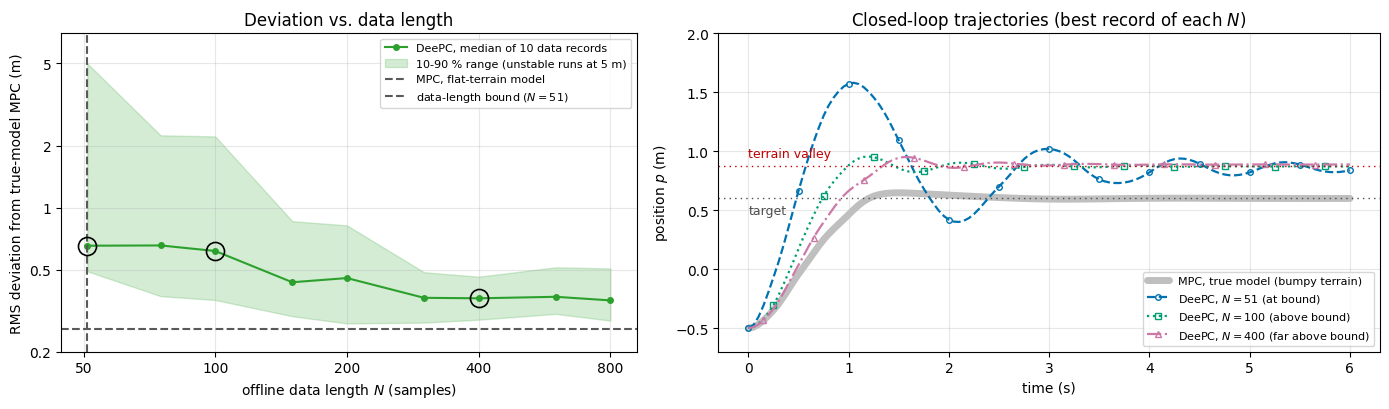

In [12]:
N_HIGHLIGHT_31 = {"at bound": 51, "above bound": 100, "far above bound": 400}
# Trajectory panel: for each highlighted T the *best* record, i.e. the one with the smallest deviation
best_seed = {label: int(np.argmin(dev_br[N_SWEEP_31.index(N)])) for label, N in N_HIGHLIGHT_31.items()}
traj_br = {label: run_cl_b(deepc_bumpy_data(N, best_seed[label]))[0] for label, N in N_HIGHLIGHT_31.items()}

# Start Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), width_ratios=[1, 1.15])
Nb = np.array(N_SWEEP_31)
x_ticks = [50, 100, 200, 400, 800]

# RMS deviation from the true-model MPC
ax[0].plot(Nb, np.median(dev_capped, axis=1), marker="o", ms=4, color=C_LEFT, label=f"DeePC, median of {N_SEEDS_31} data records")
ax[0].fill_between(Nb, np.percentile(dev_capped, 10, axis=1), np.percentile(dev_capped, 90, axis=1), color=C_LEFT, alpha=0.2,
                   label=f"10-90 % range (unstable runs at {DEV_CAP:.0f} m)")
ax[0].axhline(rms_deviation(X_flatm, X_true), color="0.35", ls="--", lw=1.5, label="MPC, flat-terrain model")
ax[0].axvline(N_BOUND, color=C_BOUND, ls="--", lw=1.5, label=f"data-length bound ($N={N_BOUND}$)")
for label, N in N_HIGHLIGHT_31.items():
    ax[0].plot(N, np.median(dev_capped[N_SWEEP_31.index(N)]), marker="o", ms=13, mfc="none", mec="k", mew=1.2, ls="none")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_ylim(0.2, 7.0)
ax[0].set_xticks(x_ticks); ax[0].set_xticklabels([str(n) for n in x_ticks])
ax[0].set_yticks([0.2, 0.5, 1.0, 2.0, 5.0]); ax[0].set_yticklabels(["0.2", "0.5", "1", "2", "5"]); ax[0].minorticks_off()
ax[0].set_xlabel("offline data length $N$ (samples)"); ax[0].set_ylabel("RMS deviation from true-model MPC (m)")
ax[0].set_title(f"Deviation vs. data length"); ax[0].legend(loc="upper right", fontsize=8)

# Trajectories of one record
ax[1].plot(t_x, X_true[:, 0], color="0.75", lw=5, solid_capstyle="round", label="MPC, true model (bumpy terrain)")
bumpy_styles = [dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), ms=4, mfc="none"),
                dict(color=OKABE_ITO[2], ls=":", marker="s", markevery=(5, 10), ms=4, mfc="none"),
                dict(color=OKABE_ITO[4], ls="-.", marker="^", markevery=(3, 10), ms=5, mfc="none")]
for j, (label, N) in enumerate(N_HIGHLIGHT_31.items()):
    ax[1].plot(t_x, traj_br[label][:, 0], lw=1.6, label=f"DeePC, $N={N}$ ({label})", **bumpy_styles[j])
ax[1].axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] - 0.05, "target", ha="left", va="top", fontsize=9, color="0.3")
ax[1].axhline(valley_p, color="#C00000", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], valley_p + 0.05, "terrain valley", ha="left", va="bottom", fontsize=9, color="#C00000")
ax[1].set_ylim(-0.7, 2.0)
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m)"); ax[1].set_title("Closed-loop trajectories (best record of each $N$)"); ax[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

#### **Results Analysis**

**More data help, and the sufficient bound from LTI case is gone.** At the bound the outcome is a lottery: two of the ten records give a closed loop that runs away, and the 10-90% range of the deviation reaches the cap. From there everything improves gradually rather than at a threshold. The unstable records disappear from $N = 150$, the median deviation falls from `0.65` m at the bound to `0.36` m from $N = 300$ on, and the 10-90% range closes from unbounded to `0.28` to `0.51` m. About six times of the bound is needed before every record is usable.

<br>

----

### **Part 4: Direct vs. Indirect Data-Driven Control**

#### **Example 4.1: DeePC vs. Identification + MPC on the Bumpy Terrain with Noisy Data**

The indirect route of Chapters 6.1 to 6.3 fits a model to the data and then runs MPC on the model. The direct route runs DeePC on the same data. When the plant is LTI and the data are perfect the two coincide (Example 1.2). We now put both in the situation of Part 3, the bumpy terrain of Chapter 6.3 with noisy learning data, and vary the noise level: $\sigma \in \{0, 10^{-4}, 10^{-3}, 3\cdot10^{-3}, 5\cdot10^{-3}, 10^{-2}\}$ m, where $5\cdot10^{-3}$ is the value of Part 3 and of Chapter 6.3. Neither method knows the terrain, and both are handed exactly the same `800` noisy samples, recorded along the task as before. Online measurements are exact and there are no constraints, as in Part 3.

Four controllers with the same cost and horizon are compared by the closed-loop cost evaluated on the *true* state:

- **Oracle:** the nonlinear MPC with the true bumpy model. The best any controller can do; it needs no data.

- **Flat-terrain model:** MPC with the exact ARX model of the *flat* car. It also needs no data and shows what physics-based modelling without terrain knowledge gives.

- **Indirect:** an ARX(2,2) model fitted to the noisy data by ordinary least squares (`identify_arx_least_squares`), then MPC on the fitted model. This is the textbook "identify, then control" pipeline.

- **Direct:** regularized DeePC on the same noisy data with the weights selected in Example 3.1.

Each noise level is repeated for ten independent realizations of the data record. The question is not whether DeePC reaches the target (Part 3 showed that no LTI predictor does on this terrain) but which of the two data-driven routes degrades more gracefully as the data get worse.

In [13]:
def make_indirect(u_d, y_d):
    a_hat, b_hat, _ = identify_arx_least_squares(u_d, y_d, order=2, input_offset=u_eq_b, output_offset=target_state[0])
    return ARXPredictiveController(env_b, dyn_b, a_hat, b_hat, Q_b_y, R_b, Qf_b_y, freq, L, name="indirect")

sigma_grid = [0.0, 1e-4, 1e-3, 3e-3, 5e-3, 1e-2]
n_seeds = 10
names = ["indirect", "DeePC"]
costs = {n: np.zeros((len(sigma_grid), n_seeds)) for n in names}
finals = {n: np.zeros((len(sigma_grid), n_seeds)) for n in names}
a_hats = np.zeros((len(sigma_grid), n_seeds, 2))
kept = {}

for i, sigma in enumerate(sigma_grid):
    for s in range(n_seeds):
        u_d, y_d = bumpy_data(N_DATA_31, s, sigma=sigma)
        a_hats[i, s], _, _ = identify_arx_least_squares(u_d, y_d, order=2, input_offset=u_eq_b, output_offset=target_state[0])
        for name, factory in [("indirect", lambda: make_indirect(u_d, y_d)),
                              ("DeePC", lambda: make_deepc_b(u_d, y_d, LAMBDA_alpha_31, LAMBDA_sigma_31))]:
            X, U, _ = run_cl_b(factory())
            costs[name][i, s] = cl_cost_b(X, U); finals[name][i, s] = X[-1, 0]
            if s == 0:
                kept[(name, sigma)] = (X, U)

failed = {n: (np.abs(finals[n] - target_state[0]) > 1.0).sum(axis=1) for n in names}   # records ending > 1 m from the target
def fmt(v):
    return f"{v:8.2f}" if v < 1e3 else "  >1e3  "
print(f"closed-loop cost, median (10-90 %) over {n_seeds} records  [records ending > 1 m from the target]")
print(f"true-model MPC {J_true_b:.2f}, flat-terrain model {J_flat_b:.2f}\n")
print(f"{'sigma (m)':>10} | {'indirect: LS-ARX + MPC':^36} | {'direct: DeePC':^36}")
for i, sigma in enumerate(sigma_grid):
    print(f"{sigma:10.0e} | " + " | ".join(f"{fmt(np.median(costs[n][i]))} ({fmt(np.percentile(costs[n][i], 10)).strip():>7}-{fmt(np.percentile(costs[n][i], 90)).strip():>7}) [{failed[n][i]:2d}]  " for n in names))
print(f"\nleast-squares ARX coefficients a = [a1, a2] (flat double integrator: [2, -1]), mean over records:")
for i, sigma in enumerate(sigma_grid):
    print(f"{sigma:10.0e}   a = {a_hats[i].mean(axis=0).round(3)}")

closed-loop cost, median (10-90 %) over 10 records  [records ending > 1 m from the target]
true-model MPC 15.27, flat-terrain model 28.35

 sigma (m) |        indirect: LS-ARX + MPC        |            direct: DeePC            
     0e+00 |    19.10 (  18.93-  19.18) [ 0]   |    29.01 (  28.82-  29.30) [ 0]  
     1e-04 |    19.10 (  18.94-  19.19) [ 0]   |    29.01 (  28.82-  29.29) [ 0]  
     1e-03 |    31.01 (  17.13-  32.33) [ 0]   |    29.10 (  28.90-  29.39) [ 0]  
     3e-03 |   >1e3   (   >1e3-   >1e3) [10]   |    29.51 (  29.34-  29.83) [ 0]  
     5e-03 |   >1e3   (   >1e3-   >1e3) [10]   |    29.83 (  29.65-  30.07) [ 0]  
     1e-02 |   >1e3   (   >1e3-   >1e3) [10]   |    30.49 (  30.25-  30.90) [ 0]  

least-squares ARX coefficients a = [a1, a2] (flat double integrator: [2, -1]), mean over records:
     0e+00   a = [ 2.13  -1.118]
     1e-04   a = [ 2.129 -1.116]
     1e-03   a = [ 2.011 -1.007]
     3e-03   a = [ 1.443 -0.479]
     5e-03   a = [ 1.02  -0.086]
     1e-02

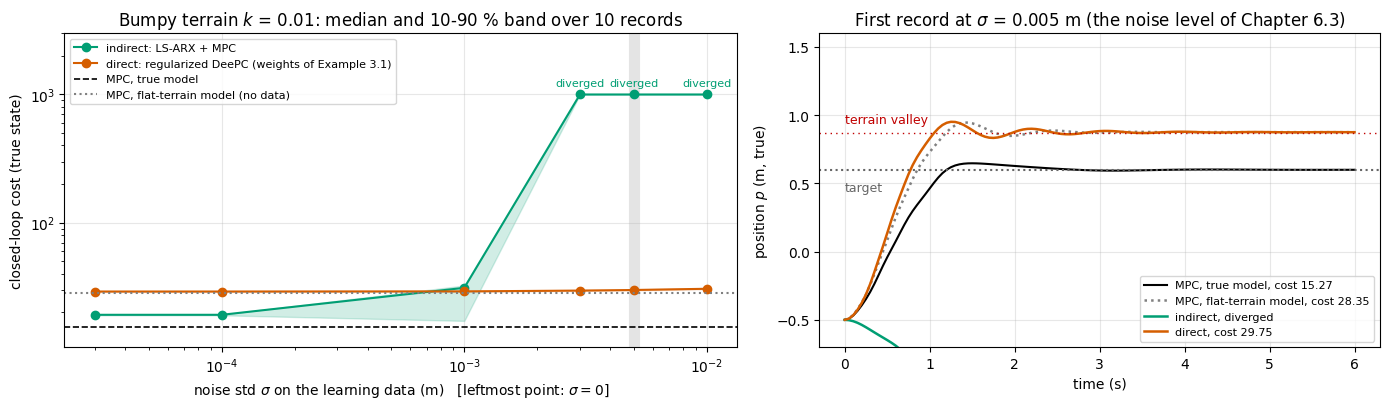

In [14]:
labels = {"indirect": "indirect: LS-ARX + MPC", "DeePC": "direct: regularized DeePC (weights of Example 3.1)"}
colors = {"indirect": OKABE_ITO[2], "DeePC": OKABE_ITO[3]}
COST_CAP = 1e3                                        # diverged runs are drawn at the cap and marked
s_plot = np.array(sigma_grid); s_plot[0] = 3e-5      # place sigma = 0 at the left edge of the log axis

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), width_ratios=[1.2, 1])
for name in names:
    med = np.minimum(np.median(costs[name], axis=1), COST_CAP)
    lo = np.minimum(np.percentile(costs[name], 10, axis=1), COST_CAP); hi = np.minimum(np.percentile(costs[name], 90, axis=1), COST_CAP)
    ax[0].plot(s_plot, med, marker="o", label=labels[name], color=colors[name])
    ax[0].fill_between(s_plot, lo, hi, color=colors[name], alpha=0.18)
    for i in np.where(np.median(costs[name], axis=1) >= COST_CAP)[0]:
        ax[0].annotate("diverged", (s_plot[i], COST_CAP), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color=colors[name])
ax[0].axhline(J_true_b, color="k", ls="--", lw=1.2, label="MPC, true model")
ax[0].axhline(J_flat_b, color="0.5", ls=":", lw=1.5, label="MPC, flat-terrain model (no data)")
ax[0].axvline(5e-3, color="0.7", lw=8, alpha=0.35, zorder=0)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_ylim(J_true_b * 0.7, COST_CAP * 3)
ax[0].set_xlabel(r"noise std $\sigma$ on the learning data (m)   [leftmost point: $\sigma=0$]"); ax[0].set_ylabel("closed-loop cost (true state)")
ax[0].set_title(f"Bumpy terrain $k$ = {K_TERRAIN_B}: median and 10-90 % band over {n_seeds} records"); ax[0].legend(fontsize=8)

sigma_show = 5e-3
ax[1].plot(t_x, X_true[:, 0], color="k", lw=1.5, label=f"MPC, true model, cost {J_true_b:.2f}")
ax[1].plot(t_x, X_flatm[:, 0], color="0.5", ls=":", lw=1.8, label=f"MPC, flat-terrain model, cost {J_flat_b:.2f}")
for name in names:
    X, U = kept[(name, sigma_show)]
    J = cl_cost_b(X, U)
    ax[1].plot(t_x, X[:, 0], color=colors[name], lw=1.8, label=f"{labels[name].split(':')[0]}, " + (f"cost {J:.2f}" if J < 1e3 else "diverged"))
ax[1].axhline(target_state[0], color="0.4", ls=":"); ax[1].axhline(valley_p, color="#C00000", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] - 0.08, "target", ha="left", va="top", fontsize=9, color="0.4")
ax[1].text(t_x[0], valley_p + 0.05, "terrain valley", ha="left", va="bottom", fontsize=9, color="#C00000")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m, true)"); ax[1].set_ylim(-0.7, 1.6)
ax[1].set_title(f"First record at $\\sigma$ = {sigma_show} m (the noise level of Chapter 6.3)"); ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

#### **Results Analysis**

**The references.** The MPC with the true model costs `15.3` and reaches the target exactly. The MPC with the flat-terrain model costs `28.4`, almost twice as much, and settles in the terrain valley beyond the target at $p = 0.88$: without terrain knowledge the constant equilibrium input it computes for $p = 0.6$ cannot hold the car on the slope, and it comes to rest where the terrain force happens to balance.

**With clean data, identification wins.** The least-squares ARX model fitted to the noise-free record costs `18.4`, only 20% above the true-model MPC, and reaches the target. Four coefficients fitted along the task path absorb the *average* effect of the terrain, and the resulting linear predictor is good enough for the receding-horizon loop to correct the rest. DeePC on the very same data costs `29.6` and stops in the same valley as the flat-terrain model, as Part 3 predicted. The difference is instructive. Least squares compresses the record into a handful of numbers and averages the nonlinearity out in the process; the DeePC coefficient $\alpha$ has to assemble each 24-step prediction from columns that carry the *local* terrain of different parts of the record, and the regularization that keeps this well posed also biases the prediction towards the flat behavior. For a plant this far from LTI, structure beats flexibility, exactly as for the BLR basis in Chapter 6.3.

**With noisy data, identification collapses and the direct route does not.** From $\sigma = 10^{-3}$ m the ARX route becomes erratic (one record diverges, the band spans `16` to `78`), and from $3\cdot10^{-3}$ m **every** record diverges: the coefficients drift from $a \approx [2.1, -1.1]$ to $a \approx [1.0, -0.1]$, the identified model no longer describes a double integrator, and without input bounds the controller drives the car away without limit. The mechanism is the errors-in-variables bias of least squares, familiar from the flat plant, but here it acts on a model that was already stretched to cover a nonlinearity. DeePC, in contrast, costs `29.6` to `30.2` across the **entire** noise range, with a band of a few tenths and no failed record. It never does better than the flat-terrain model, but noise on the data does not hurt it either: the same regularized least-squares fit of the history that limits its performance also makes it insensitive to the quality of the record.

**Reading the result next to Chapter 6.3.** At $\sigma = 5\cdot10^{-3}$ m the costs relative to the true-model MPC are `1.86` for the flat-terrain model and `1.95` for DeePC, and the ARX route has diverged. The GP-based controller of Chapter 6.3 reaches `1.48` on the same terrain and the same noise level (with a speed limit and a different sensor, so the number is indicative rather than comparable). Only the method that learns the terrain nonlinearity gets below the flat-model floor. LTI-based data-driven control, direct or indirect, cannot, and on this terrain the honest choice between the two LTI routes is between a high but fragile peak (identification) and a low but reliable plateau (DeePC).

<blockquote style="
    padding: 18px 20px;
    margin: 1.2em 0;
    background: rgba(56, 139, 253, 0.12);      
    border-left: 4px solid rgba(56, 139, 253, 0.85);
    border-radius: 6px;
    color: inherit !important;                  
">

##### **Takeaway:**

- **One sufficiently rich trajectory replaces the model.** The Hankel matrix is a complete substitute for the state-space model, and the recent input-output history is a complete substitute for the state. DeePC replaces the trajectory generator inside MPC and nothing else: on a deterministic LTI plant it **coincides with model-based MPC** to solver precision.

- **On an LTI plant the data requirement is a rank condition, and once it holds more data change nothing.** Persistency of excitation of the input of order $L + T_{\mathrm{ini}} + n_x$ is sufficient and can be imposed before the experiment, at $N \ge (n_u+1)(L + T_{\mathrm{ini}} + n_x) - 1$; the generalized condition on the recorded input-output data is necessary and sufficient and is met a little earlier. Above it the predictor is exact and further samples only enlarge the QP.

- **On the nonlinear plant with observation noise neither statement survives.** The regularization weights decide whether the loop is stable at all, and only a narrow window of them works. More data still help, but gradually and with a floor: on this terrain the result settles at the level of the MPC with the flat-terrain model.

- **Direct versus indirect is a trade between peak and plateau.** With clean data least-squares identification comes within 25% of the true-model MPC (cost `19.1` against `15.3`) but diverges on every record once the data carry millimetre-level noise; DeePC stays between `29.0` and `30.5` at every noise level and never fails. 
</blockquote>

**References:** Willems, Rapisarda, Markovsky, and De Moor, *A note on persistency of excitation*, Systems & Control Letters, 2005. Coulson, Lygeros, and Dörfler, *Data-Enabled Predictive Control: In the Shallows of the DeePC*, ECC 2019. Berberich, Köhler, Müller, and Allgöwer, *Data-Driven Model Predictive Control With Stability and Robustness Guarantees*, IEEE TAC 2021. Dörfler, Coulson, and Markovsky, *Bridging Direct & Indirect Data-Driven Control Formulations via Regularizations and Relaxations*, IEEE TAC 2023.

<br>

----

### **Appendix: Figures for the Tutorial Paper**

The cell below redraws the results of Examples 2.1, 3.1 and 3.2 at single-column width in the notation of the tutorial paper (data length $N$, slack weight $\lambda_\sigma$ for `lambda_sigma`, coefficient weight $\lambda_\alpha$ for `lambda_alpha`) and saves them to `figures/`. It contains no new computation.

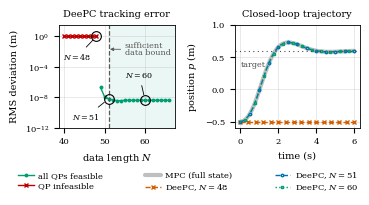

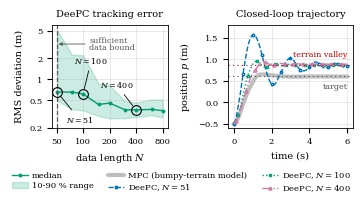

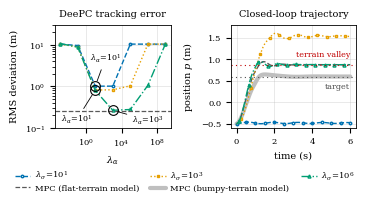

In [15]:
import matplotlib as mpl
# Same style as the figures of Chapter 6.3, so that all tutorial-paper figures match:
# serif text and mathtext, Type 42 (TrueType) fonts in the PDF, 7 pt text and 6 pt ticks.
PAPER_RC = {"font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7,
            "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
            "axes.linewidth": 0.6, "lines.linewidth": 1.0,
            "font.family": "serif", "mathtext.fontset": "dejavuserif", "pdf.fonttype": 42,
            "lines.markersize": 1.8, "axes.grid": True, "grid.linewidth": 0.4, "grid.alpha": 0.5,
            "legend.handlelength": 1.9, "legend.borderpad": 0.2, "legend.labelspacing": 0.25,
            "legend.columnspacing": 1.0, "legend.handletextpad": 0.5}
C_RED, C_GRN, C_GRY, C_PRP = "#C00000", OKABE_ITO[2], "0.35", OKABE_ITO[4]
P_RANGE_PAPER = (-0.6, 1.6)
# Styles and label offsets are indexed by position in the highlight dict, not by its keys,
# so the highlighted cases can be renamed without breaking these figures.
ROLE_STYLE = [dict(color=OKABE_ITO[3], ls="--", marker="x", markevery=8, ms=2.2),
              dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), mfc="none"),
              dict(color=OKABE_ITO[2], ls=":",  marker="s", markevery=(5, 10), mfc="none")]
ROLE_STYLE_31 = [dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), mfc="none"),
                 dict(color=OKABE_ITO[2], ls=":",  marker="s", markevery=(5, 10), mfc="none"),
                 dict(color=C_PRP,       ls="-.", marker="^", markevery=(3, 10), ms=2.2, mfc="none")]
CIRCLE = dict(marker="o", ms=7.0, mfc="none", mec="k", mew=0.8, ls="none")
valleys_all = (2 * np.arange(-2, 8) + 1) * np.pi / 18
valley_p = float(valleys_all[valleys_all > target_state[0]][0])          # first terrain valley beyond the target

def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight", dpi=300)

ANN_FS = 5.8                                                   # annotation text (N = ..., lambda = ..., target, bound); titles, ticks, legend unchanged

def target_line(a, side="left"):
    a.axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=0.8)
    x, ha = (t_x[0], "left") if side == "left" else (t_x[-1], "right")
    a.text(x, target_state[0] - 0.15, "target", ha=ha, va="top", fontsize=ANN_FS, color="0.3")

def valley_line(a, side="right"):
    a.axhline(valley_p, color=C_RED, ls=(0, (1, 3)), lw=0.8)
    x, ha = (t_x[0], "left") if side == "left" else (t_x[-1], "right")
    a.text(x, valley_p + 0.15, "terrain valley", ha=ha, va="bottom", fontsize=ANN_FS, color=C_RED)

def bound_note(a, x_text, y_text, x_line):
    """Label the vertical dashed line as the sufficient data-length bound, with a short arrow to it."""
    a.annotate("sufficient\ndata bound", xy=(x_line, y_text), xytext=(x_text, y_text), ha="left", va="center",
               fontsize=ANN_FS, color=C_GRY, linespacing=0.9,
               arrowprops=dict(arrowstyle="-|>", color=C_GRY, lw=0.6, shrinkA=1, shrinkB=1, mutation_scale=5))

def paper_figure(legend_rows):
    fig = plt.figure(figsize=(3.5, 1.65 + 0.13 * legend_rows))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.13 * legend_rows], width_ratios=[1, 1.08], hspace=0.62, wspace=0.5,
                          left=0.13, right=0.99, top=0.91, bottom=0.02)
    return fig, fig.add_subplot(gs[1, :]), [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

def shared_legend(axes, lax, ncol, mpc_last=False):
    h, l = [], []
    for a_ in axes:
        for hh, ll in zip(*a_.get_legend_handles_labels()):
            if ll not in l: h.append(hh); l.append(ll)
    if mpc_last:
        order = [i for i, ll in enumerate(l) if not ll.startswith("MPC")] + [i for i, ll in enumerate(l) if ll.startswith("MPC")]
        h, l = [h[i] for i in order], [l[i] for i in order]
    lax.axis("off")
    pos = lax.get_position()
    lax.figure.legend(h, l, loc="upper left", bbox_to_anchor=(0.01, pos.y0, 0.98, pos.height), mode="expand", ncol=ncol,
                      frameon=False, borderaxespad=0.0)

ann_kw = dict(textcoords="offset points", fontsize=ANN_FS, color="k", arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkB=4))

# ============ figure 1: flat terrain, data length (Example 2.1) ==================================
with mpl.rc_context(PAPER_RC):
    fig, lax, (a, b) = paper_figure(legend_rows=2)
    a.semilogy(Ns[ok], np.maximum(devs[ok], 1e-12), marker="o", color=C_GRN, label="all QPs feasible")
    a.semilogy(Ns[~ok], devs[~ok], marker="x", ms=2.6, color=C_RED, label="QP infeasible")
    a.axvline(N_BOUND, color=C_GRY, ls="--", lw=0.9)
    a.set_ylim(1e-12, 30); xl = a.get_xlim(); a.axvspan(N_BOUND, xl[1], color=C_GRN, alpha=0.08, lw=0, zorder=0); a.set_xlim(*xl)
    offsets = [(-14, -17), (-16, -15), (-4, 16)]
    for (row, _), off in zip(highlight.values(), offsets):
        a.annotate(f"$N={row['N']}$", (row['N'], max(row['dev'], 1e-12)), xytext=off, ha="center", **ann_kw)
        a.plot(row['N'], max(row['dev'], 1e-12), **CIRCLE)
    bound_note(a, 55, 2e-2, N_BOUND)
    a.set_yticks([1e-12, 1e-8, 1e-4, 1e0]); a.set_xlabel("data length $N$"); a.set_ylabel("RMS deviation (m)"); a.set_title("DeePC tracking error")
    b.plot(t_x, X_mpc_flat[:, 0], color="0.75", lw=3.0, solid_capstyle="round", label="MPC (full state)")
    for j, (label, N) in enumerate(N_HIGHLIGHT.items()): b.plot(t_x, highlight[label][1][:, 0], label=f"DeePC, $N={N}$", **ROLE_STYLE[j])
    target_line(b, side="left"); b.set_ylim(-0.6, 1.0); b.set_xlabel("time (s)"); b.set_ylabel("position $p$ (m)"); b.set_title("Closed-loop trajectory")
    shared_legend([a, b], lax, ncol=3)
    savefig(fig, "tutorial_deepc_flat"); plt.show()

# ============ figure 2: bumpy terrain, data length (Example 3.1) =================================
with mpl.rc_context(PAPER_RC):
    fig, lax, (a, b) = paper_figure(legend_rows=2)
    a.plot(Nb, np.median(dev_capped, axis=1), marker="o", color=C_GRN, label="median")
    a.fill_between(Nb, np.percentile(dev_capped, 10, axis=1), np.percentile(dev_capped, 90, axis=1), color=C_GRN, alpha=0.2, label="10-90 % range")
    a.axvline(N_BOUND, color=C_GRY, ls="--", lw=0.9)
    offsets = [((6, -22), "left"), ((18, 22), "right"), ((-2, 16), "right")]
    for (label, N), off in zip(N_HIGHLIGHT_31.items(), offsets):
        a.annotate(f"$N={N}$", (N, np.median(dev_capped[N_SWEEP_31.index(N)])), xytext=off[0], ha=off[1], **ann_kw)
        a.plot(N, np.median(dev_capped[N_SWEEP_31.index(N)]), **CIRCLE)
    a.set_xscale("log"); xt = [50, 100, 200, 400, 800]
    a.set_xticks(xt); a.set_xticklabels([str(t) for t in xt]); a.set_yscale("log"); a.set_ylim(0.2, 6.0); a.set_yticks([0.2, 0.5, 1.0, 2.0, 5.0]); a.set_yticklabels(["0.2", "0.5", "1", "2", "5"]); a.minorticks_off()
    bound_note(a, 118, 3.2, N_BOUND)
    a.set_xlabel("data length $N$"); a.set_ylabel("RMS deviation (m)"); a.set_title("DeePC tracking error")
    b.plot(t_x, X_true_br[:, 0], color="0.75", lw=3.0, solid_capstyle="round", label="MPC (bumpy-terrain model)")
    for j, (label, N) in enumerate(N_HIGHLIGHT_31.items()): b.plot(t_x, traj_br[label][:, 0], label=f"DeePC, $N={N}$", **ROLE_STYLE_31[j])
    valley_line(b, side="right"); target_line(b, side="right"); b.set_ylim(-0.6, 1.8); b.set_xlabel("time (s)"); b.set_ylabel("position $p$ (m)"); b.set_title("Closed-loop trajectory")
    shared_legend([a, b], lax, ncol=3)
    savefig(fig, "tutorial_deepc_bumpy"); plt.show()

# ============ figure 3: regularization (Example 3.1) =============================================
with mpl.rc_context(PAPER_RC):
    fig, lax, (a, b) = paper_figure(legend_rows=2)
    # one line style per lambda_sigma, shared by the left curves and the right trajectories
    SIG_STYLE = [dict(ls="--", marker="o", markevery=(0, 10), mfc="none"), dict(ls=":", marker="s", markevery=(5, 10), mfc="none"),
                 dict(ls="-.", marker="^", markevery=(3, 10), ms=2.2, mfc="none")]
    for isigma, lsigma in enumerate(LAMBDA_sigma_GRID):
        stl = {k: v for k, v in SIG_STYLE[isigma].items() if k != "markevery"}
        a.loglog(LAMBDA_alpha_GRID, np.minimum(dev_grid[isigma], 30), color=OKABE_ITO[isigma], label=f"$\\lambda_\\sigma\\!=\\!10^{{{int(np.log10(lsigma))}}}$", **stl)
    a.axhline(rms_deviation(X_flatm, X_true), color=C_GRY, ls="--", lw=0.9, label="MPC (flat-terrain model)")
    lam_offsets = [((-4, 18), "left"), ((-2, -23.5), "right"), ((14, -9), "left")]         # one per entry of TRAJECTORY_SETTINGS
    for (lalpha, lsigma), (off, ha) in zip(TRAJECTORY_SETTINGS, lam_offsets):
        y_c = min(dev_grid[LAMBDA_sigma_GRID.index(lsigma), LAMBDA_alpha_GRID.index(lalpha)], 30)
        a.plot(lalpha, y_c, **CIRCLE)
        a.annotate(f"$\\lambda_\\alpha\\!=\\!10^{{{int(np.log10(lalpha))}}}$", (lalpha, y_c), xytext=off, ha=ha, **ann_kw)
    a.set_ylim(0.1, 30)
    a.set_xlabel(r"$\lambda_\alpha$"); a.set_ylabel("RMS deviation (m)"); a.set_title("DeePC tracking error")
    b.plot(t_x, X_true[:, 0], color="0.75", lw=3.0, solid_capstyle="round", label="MPC (bumpy-terrain model)")
    b.plot(t_x, X_flatm[:, 0], color=C_GRY, ls="--")
    for lalpha, lsigma in TRAJECTORY_SETTINGS:
        isigma = LAMBDA_sigma_GRID.index(lsigma)
        b.plot(t_x, traj_bumpy[(lalpha, lsigma)][:, 0], color=OKABE_ITO[isigma], **SIG_STYLE[isigma])
    valley_line(b, side="right"); target_line(b, side="right"); b.set_ylim(-0.6, 1.8); b.set_xlabel("time (s)"); b.set_ylabel("position $p$ (m)"); b.set_title("Closed-loop trajectory")
    # legend as in the paper: first row the three lambda_sigma curves, second row the two MPC references
    hl = {}
    for a_ in (a, b):
        for hh, ll in zip(*a_.get_legend_handles_labels()):
            hl.setdefault(ll, hh)
    labels_sig = [l for l in hl if l.startswith("$\\lambda")]
    labels_mpc = [l for l in hl if l.startswith("MPC")]
    order = []                                                     # column-major fill of a 2 x 3 grid -> row-major appearance
    for i in range(3):
        order.append(labels_sig[i])
        if i < len(labels_mpc): order.append(labels_mpc[i])
    lax.axis("off"); pos = lax.get_position()
    fig.legend([hl[l] for l in order], order, loc="upper left", bbox_to_anchor=(0.01, pos.y0, 0.98, pos.height), mode="expand",
               ncol=3, frameon=False, borderaxespad=0.0)
    savefig(fig, "tutorial_deepc_regularization"); plt.show()